In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits

from specula.mmlib.analyse_data import get_sim_data
from specula.mmlib.utils import show_psf, get_reference_psf
from specula.lib.radial_profile import compute_radial_profile

2026-05-25 16:30:23,910 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-05-25 16:30:24,033 [INFO]: [specula]: Default device is GPU number 0
2026-05-25 16:30:25,114 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-05-25 16:30:25,114 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-05-25 16:30:25,115 [INFO]: [specula]: Default device is GPU number 0
2026-05-25 16:30:25,115 [INFO]: [specula]: Default device is GPU number 0


In [53]:
def calc_coro_psf(phase,amp,use_average_field:bool=True,norm=None,oversampling:int=4):    
    L = np.max(phase.shape)
    phase -= np.mean(phase)
    pad_amp = np.pad(amp, int((oversampling-1)/2*L), mode='constant', constant_values=0.0)
    pad_phase = np.pad(phase, int((oversampling-1)/2*L), mode='constant', constant_values=0.0)
    electric_field = pad_amp * np.exp(1j * pad_phase, dtype=complex)
    pupil_mask = pad_amp > 0
    if use_average_field is True: # average field removal
        avg_electric_field = np.sum(electric_field * pupil_mask) / np.sum(pupil_mask)
        electric_field_corrected = electric_field - avg_electric_field * pupil_mask
    else: # perfect coronagraph formula (Cavarroc et al. 2006, Eq. 1)
        mean_phase = np.sum(pad_phase * pupil_mask) / np.sum(pupil_mask)
        var_phase = np.sum(((pad_phase - mean_phase) ** 2) * pupil_mask) / np.sum(pupil_mask)
        ec = np.exp(-var_phase)
        coherent_core = np.sqrt(ec) * np.exp(1j * mean_phase, dtype=complex) * pad_amp
        electric_field_corrected = electric_field - coherent_core * pupil_mask

    focal_field = np.fft.fft2(electric_field_corrected)
    focal_field = np.fft.fftshift(focal_field)

    # Calculate PSF as square modulus
    coronagraph_psf = np.abs(focal_field*np.conj(focal_field))
    if norm is None:
        norm = np.sum(coronagraph_psf)
    coronagraph_psf /= norm
    return coronagraph_psf

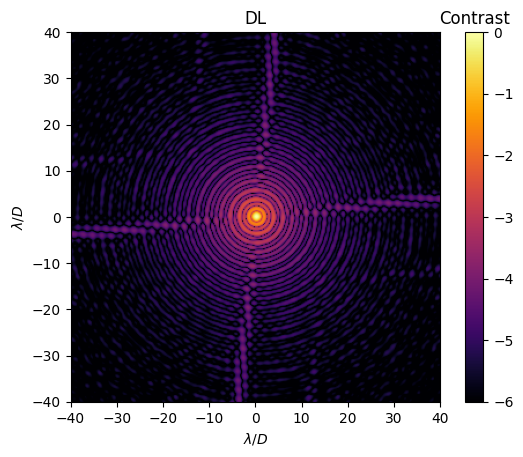

In [64]:
cascading_dir = '/raid1/mmenessini/results/Cascading'
xao_dir = '/raid1/mmenessini/results/XAO'
ekarus_dir = '/raid1/mmenessini/results/EKARUS'
calib_dir = '/raid1/mmenessini/calibration/XAO'

oversampling = 4
pupil_tag = 'vlt_pupil_160pixels'
psf_dl = get_reference_psf(root_dir=calib_dir,pupil_tag=pupil_tag,nd=oversampling)

show_psf(psf_dl, title='DL', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-6, maxVal=np.max(psf_dl))

Using data directory: /raid1/mmenessini/results/EKARUS/20260525_180204
key: coro_psf_std_profile type: <class 'numpy.ndarray'>
key: atmo_phase type: <class 'numpy.ndarray'>
key: coro_psf_int_profile type: <class 'numpy.ndarray'>


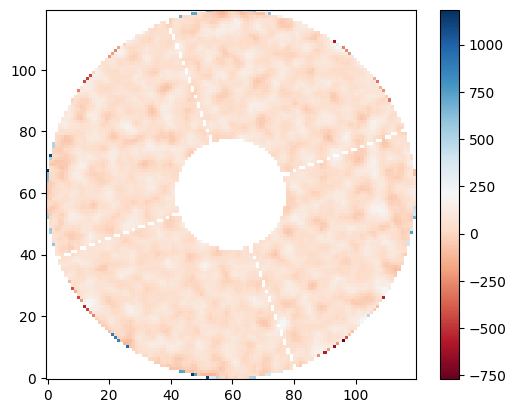

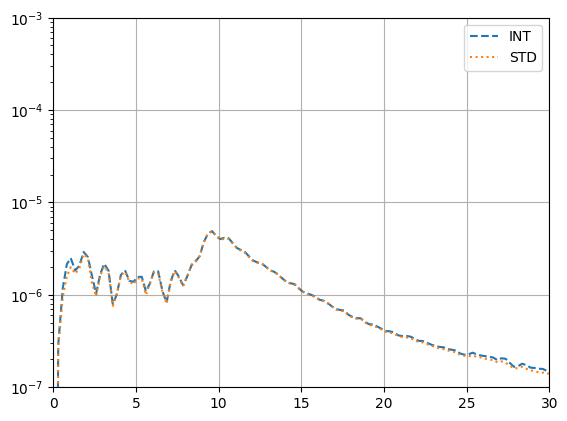

In [77]:
data = get_sim_data(root_dir=ekarus_dir)

try:
    phases = data['atmo_phase'][:,1,:,:]
    mask = data['atmo_phase'][0,0,:,:]==0
    plt.figure()
    plt.imshow(np.ma.masked_array(phases[0]-np.mean(phases[0]),mask=mask),origin='lower',cmap='RdBu')
    plt.colorbar()
except KeyError:
    pass
coro_std = data['coro_psf_std_profile'][0]
coro_int = data['coro_psf_int_profile'][0]

plt.figure()
plt.semilogy(coro_int[0],coro_int[1],'--',label='INT')
plt.semilogy(coro_std[0],coro_std[1],':',label='STD')
plt.ylim([1e-7,1e-3])
plt.xlim([0,30])
plt.legend()
plt.grid()

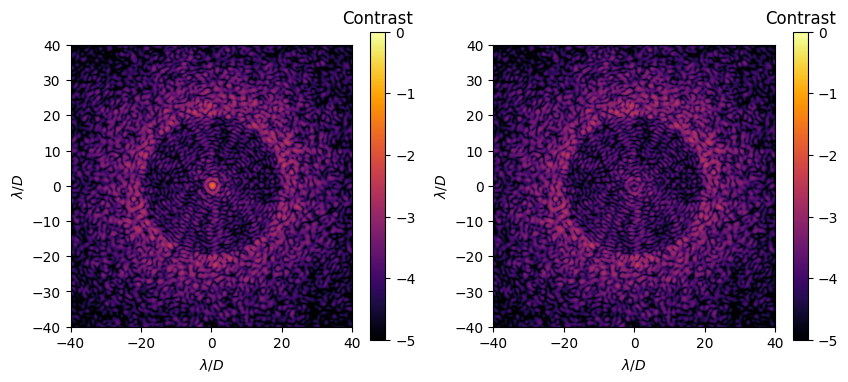

In [57]:
test_coro_psf = calc_coro_psf(phase=phases[100]*2*np.pi/750,amp=1-mask,use_average_field=False)
test_coro_psf_avg = calc_coro_psf(phase=phases[100]*2*np.pi/750,amp=1-mask,use_average_field=True)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
show_psf(test_coro_psf, cmap='inferno', ext=0.5, oversampling=4, vmin=-5, maxVal=np.max(psf_dl))
plt.subplot(1,2,2)
show_psf(test_coro_psf_avg, cmap='inferno', ext=0.5, oversampling=4, vmin=-5, maxVal=np.max(psf_dl))

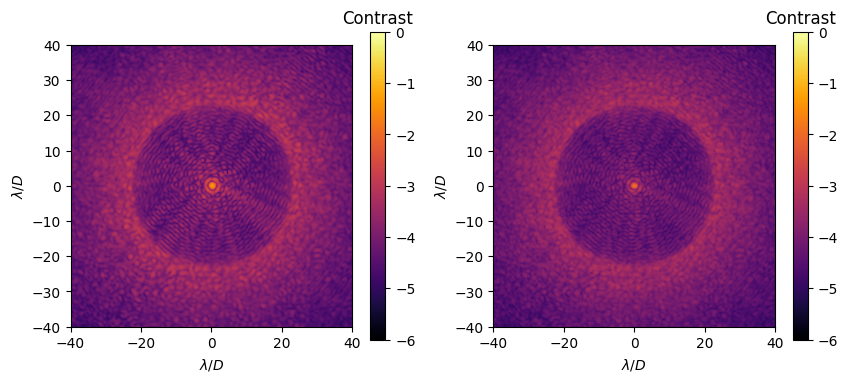

In [48]:
coro_psf_int = np.zeros_like(test_coro_psf)
coro_psf_std = np.zeros_like(test_coro_psf)
N = 1000
for j in range(N):
    coro_psf_int += calc_coro_psf(phase=phases[j]*2*np.pi/750,amp=1-mask,use_average_field=False)/N

for j in range(N):
    coro_psf_std += (calc_coro_psf(phase=phases[j]*2*np.pi/750,amp=1-mask,use_average_field=False)-coro_psf_int)**2/N
coro_psf_std = np.sqrt(coro_psf_std)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
show_psf(coro_psf_int, cmap='inferno', ext=0.5, oversampling=4, vmin=-6, maxVal=np.max(psf_dl))
plt.subplot(1,2,2)
show_psf(coro_psf_std, cmap='inferno', ext=0.5, oversampling=4, vmin=-6, maxVal=np.max(psf_dl))

In [17]:
tn1kHz = '20260520_102745'
tn2kHz = '20260520_110242'
tn4kHz = '20260520_115326'
tnMod1 = '20260520_120617'
tnMod0 = '20260520_123548'

# Cascading
tnSAO = '20260521_170926' # cascading_iirfilter_1300modes, g = 0.15
tnCAO = '20260521_172032' # int g=0.4, iirfilter_300modes g = 0.2

Using data directory: /raid1/mmenessini/results/Cascading/20260521_170926
key: sr1 type: <class 'numpy.ndarray'>
key: dm1_res type: <class 'numpy.ndarray'>
key: dm2_cmd type: <class 'numpy.ndarray'>
key: atmo_res type: <class 'numpy.ndarray'>
key: dm1_cmd type: <class 'numpy.ndarray'>
key: sr2 type: <class 'numpy.ndarray'>
key: coro_psf2 type: <class 'numpy.ndarray'>
key: coro_psf1 type: <class 'numpy.ndarray'>
key: dm2_res type: <class 'numpy.ndarray'>
Using data directory: /raid1/mmenessini/results/Cascading/20260521_172032
key: sr1 type: <class 'numpy.ndarray'>
key: dm1_res type: <class 'numpy.ndarray'>
key: dm2_cmd type: <class 'numpy.ndarray'>
key: atmo_res type: <class 'numpy.ndarray'>
key: dm1_cmd type: <class 'numpy.ndarray'>
key: sr2 type: <class 'numpy.ndarray'>
key: coro_psf2 type: <class 'numpy.ndarray'>
key: coro_psf1 type: <class 'numpy.ndarray'>
key: dm2_res type: <class 'numpy.ndarray'>


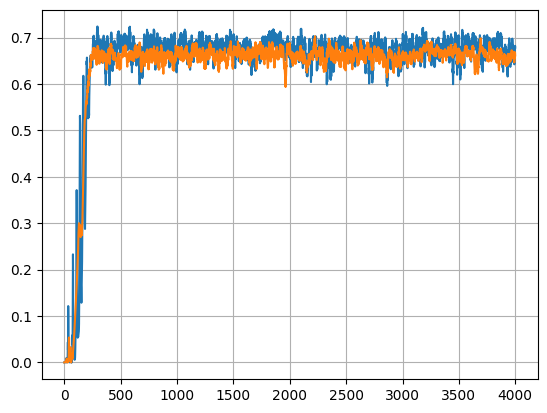

In [18]:
dataSAO = get_sim_data(root_dir=cascading_dir,tn=tnSAO)
dataCAO = get_sim_data(root_dir=cascading_dir,tn=tnCAO)

sr = dataSAO['sr2']
srCAO = dataCAO['sr2']

plt.figure()
plt.plot(sr)
plt.plot(srCAO)
plt.grid()

Using data directory: /raid1/mmenessini/results/XAO/20260520_102745
key: coro_psf type: <class 'numpy.ndarray'>
key: sr type: <class 'numpy.ndarray'>
key: dm_cmd type: <class 'numpy.ndarray'>
key: coro_opt_psf type: <class 'numpy.ndarray'>
key: atmo_res type: <class 'numpy.ndarray'>
key: pyr_modes type: <class 'numpy.ndarray'>
key: dm_res type: <class 'numpy.ndarray'>
Using data directory: /raid1/mmenessini/results/XAO/20260520_110242
key: coro_psf type: <class 'numpy.ndarray'>
key: sr type: <class 'numpy.ndarray'>
key: dm_cmd type: <class 'numpy.ndarray'>
key: coro_opt_psf type: <class 'numpy.ndarray'>
key: atmo_res type: <class 'numpy.ndarray'>
key: pyr_modes type: <class 'numpy.ndarray'>
key: dm_res type: <class 'numpy.ndarray'>
Using data directory: /raid1/mmenessini/results/XAO/20260520_115326
key: coro_psf type: <class 'numpy.ndarray'>
key: sr type: <class 'numpy.ndarray'>
key: dm_cmd type: <class 'numpy.ndarray'>
key: atmo_res type: <class 'numpy.ndarray'>
key: pyr_modes type: <

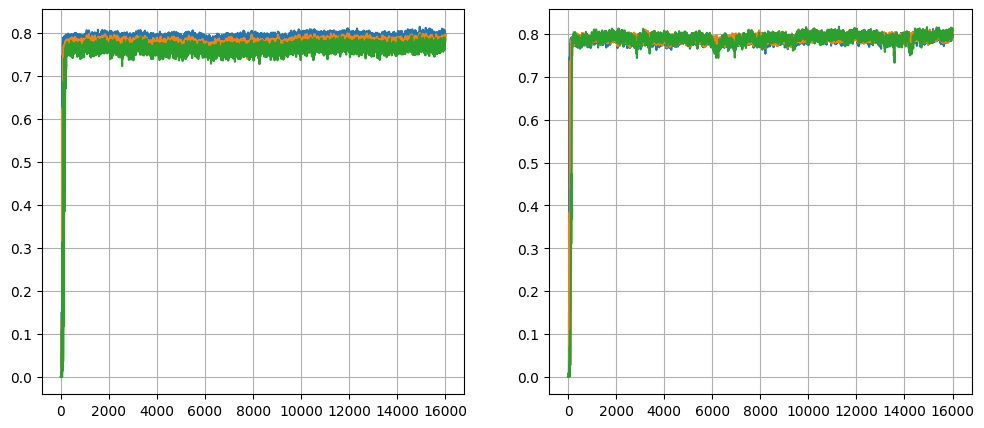

In [21]:
data1kHz = get_sim_data(root_dir=xao_dir,tn=tn1kHz)
data2kHz = get_sim_data(root_dir=xao_dir,tn=tn2kHz)
data4kHz = get_sim_data(root_dir=xao_dir,tn=tn4kHz)
dataMod1 = get_sim_data(root_dir=xao_dir,tn=tnMod1)
dataMod0 = get_sim_data(root_dir=xao_dir,tn=tnMod0)

sr1k = data1kHz['sr']
sr2k = data2kHz['sr']
sr4k = data4kHz['sr']
sr1 = dataMod1['sr']
sr0 = dataMod0['sr']

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(sr4k)
plt.plot(sr2k)
plt.plot(sr1k)
plt.grid()
plt.subplot(1,2,2)
plt.plot(sr4k)
plt.plot(sr1)
plt.plot(sr0)
plt.grid()

In [12]:
dt = 0.00025
init = int(0.5/dt)

In [ ]:
coro_psf1kHz = data1kHz['coro_psf']
opt_coro_psf = data1kHz['coro_opt_psf']

coro_psf1kHz_std = np.sqrt(np.mean(coro_psf1kHz[init:]**2,axis=0))
opt_coro_psf_std = np.std(opt_coro_psf,axis=0) #np.sqrt(np.mean(opt_coro_psf[init:]**2,axis=0))

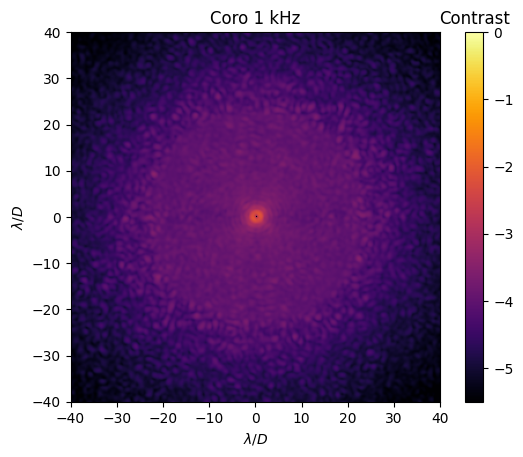

In [19]:
coro_psf = dataSAO['coro_psf2']
coro_psf_std = np.mean(coro_psf[init:],axis=0) #[init:]**2
plt.figure()
show_psf(coro_psf_std, title='Coro 1 kHz', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))

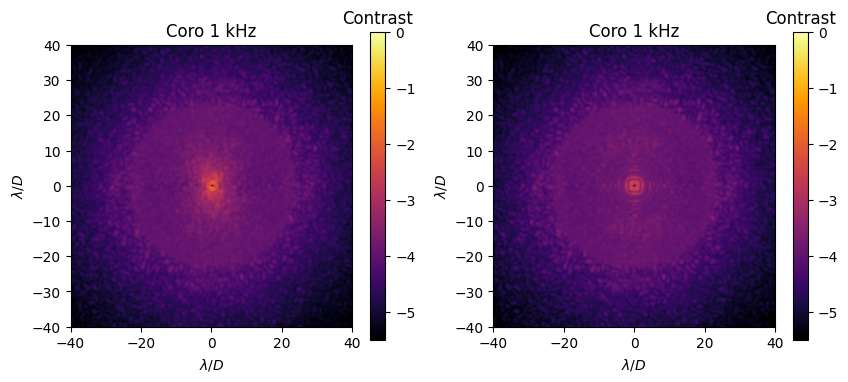

In [20]:
coro_psf1 = dataCAO['coro_psf1']
coro_psf1_std = np.mean(coro_psf1[init:],axis=0) #[init:]**2
coro_psf2 = dataCAO['coro_psf2']
coro_psf2_std = np.mean(coro_psf2[init:],axis=0) #[init:]**2
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
show_psf(coro_psf1_std, title='Coro 1 kHz', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))
plt.subplot(1,2,2)
show_psf(coro_psf2_std, title='Coro 1 kHz', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))

In [ ]:
coro_psf2kHz = data2kHz['coro_psf']
coro_psf2kHz_std = np.sqrt(np.mean(coro_psf2kHz[init:]**2,axis=0))

coro_psf4kHz = data4kHz['coro_psf']
coro_psf4kHz_std = np.sqrt(np.mean(coro_psf4kHz[init:]**2,axis=0))

In [34]:
coro_psfmod1 = dataMod1['coro_psf']
coro_psfmod1_std = np.sqrt(np.mean(coro_psfmod1[init:]**2,axis=0))

coro_psfmod0 = dataMod0['coro_psf']
coro_psfmod0_std = np.sqrt(np.mean(coro_psfmod0[init:]**2,axis=0))

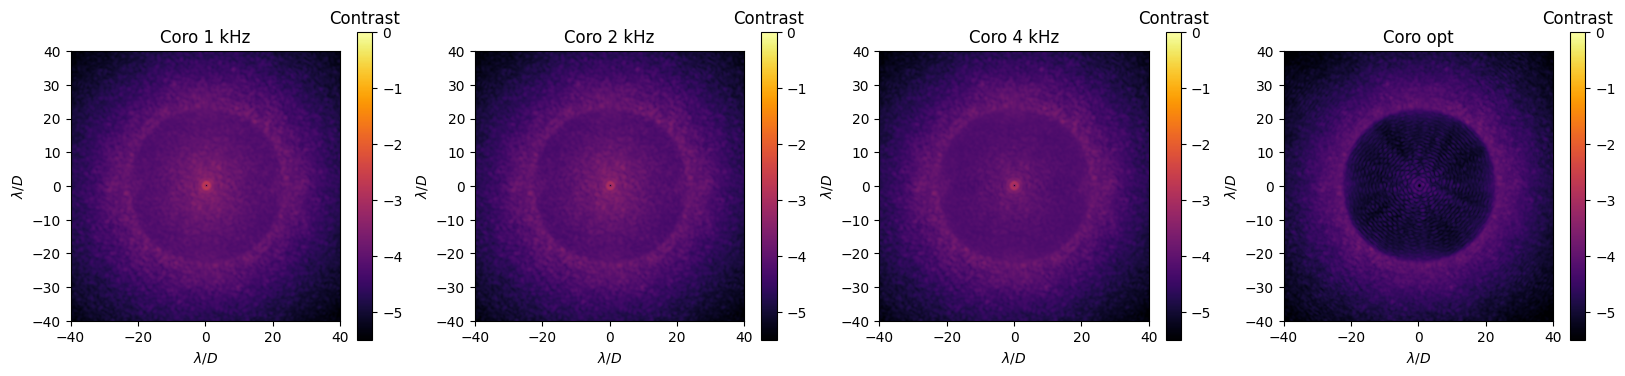

In [35]:
plt.figure(figsize=(20,4))
plt.subplot(1,4,1)
show_psf(coro_psf1kHz_std, title='Coro 1 kHz', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))
plt.subplot(1,4,2)
show_psf(coro_psf2kHz_std, title='Coro 2 kHz', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))
plt.subplot(1,4,3)
show_psf(coro_psf4kHz_std, title='Coro 4 kHz', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))
plt.subplot(1,4,4)
show_psf(opt_coro_psf_std, title='Coro opt', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))

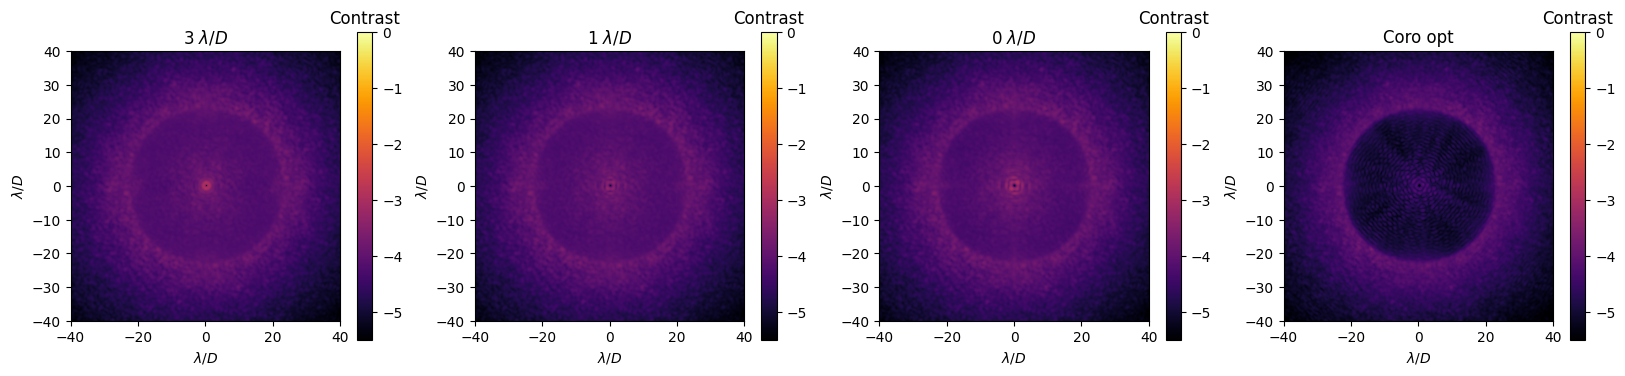

In [36]:
plt.figure(figsize=(20,4))
plt.subplot(1,4,1)
show_psf(coro_psf4kHz_std, title=r'3 $\lambda/D$', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))
plt.subplot(1,4,2)
show_psf(coro_psfmod1_std, title=r'1 $\lambda/D$', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))
plt.subplot(1,4,3)
show_psf(coro_psfmod0_std, title=r'0 $\lambda/D$', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))
plt.subplot(1,4,4)
show_psf(opt_coro_psf_std, title='Coro opt', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))

In [37]:
# rad_psf_dl, dist = compute_radial_profile(psf_dl)
rad_psf1kHz_coro, dist = compute_radial_profile(coro_psf1kHz_std)
rad_psf2kHz_coro, dist = compute_radial_profile(coro_psf2kHz_std)
rad_psf4kHz_coro, dist = compute_radial_profile(coro_psf4kHz_std)
rad_psfmod1_coro, dist = compute_radial_profile(coro_psfmod1_std)
rad_psfmod0_coro, dist = compute_radial_profile(coro_psfmod0_std)
rad_psf_opt_coro, dist = compute_radial_profile(opt_coro_psf_std)
# rad_psf2kHz_opt_coro, dist = compute_radial_profile(opt_coro_psf2kHz_std)

Text(0.5, 0, '$\\lambda/D$')

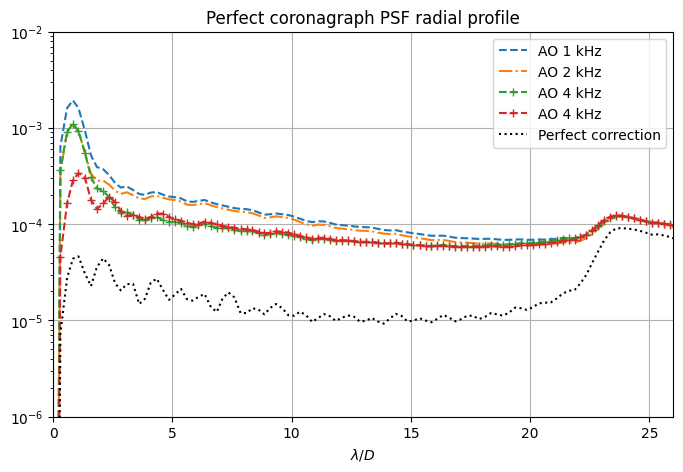

In [38]:

plt.figure(figsize=(8,5))
plt.plot(dist/oversampling, rad_psf1kHz_coro/np.max(psf_dl), '--', label=r'AO 1 kHz')
plt.plot(dist/oversampling, rad_psf2kHz_coro/np.max(psf_dl), '-.', label=r'AO 2 kHz')
plt.plot(dist/oversampling, rad_psf4kHz_coro/np.max(psf_dl), '--+', label=r'AO 4 kHz')
plt.plot(dist/oversampling, rad_psfmod1_coro/np.max(psf_dl), '--+', label=r'AO 4 kHz')
# plt.plot(dist/oversampling, rad_psfmod0_coro/np.max(psf_dl), '--+', label=r'AO 4 kHz')
plt.plot(dist/oversampling, rad_psf_opt_coro/np.max(psf_dl), ':', c='k', label=r'Perfect correction')
plt.legend()
plt.yscale('log')
plt.xlim([0,26])
plt.ylim([1e-6,1e-2])
plt.grid()
plt.title('Perfect coronagraph PSF radial profile')
plt.xlabel(r'$\lambda/D$')